In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
df = pd.read_csv('/content/magic04.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,10
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [3]:
df.columns = ['fLength', 'fWidth', 'fSize', 'fConc', 'fConc1', 'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class']
df = df.drop(['class'], axis=1)
df.head()

,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620


# Principal Component

In [4]:
cov_matrix = df.cov().values
cov_matrix

array([[ 1.79478093e+03,  5.98863542e+02,  1.40642293e+01,
        -4.88699477e+00, -2.80038030e+00, -9.24434103e+02,
        -2.58727155e+02,  1.18140078e+01, -9.70681761e+00,
         1.32486413e+03],
       [ 5.98863542e+02,  3.36577782e+02,  6.22110176e+00,
        -2.04513685e+00, -1.17822641e+00, -2.89972346e+02,
        -1.64893734e+02,  1.51860869e+01,  3.16366938e+01,
         4.61786200e+02],
       [ 1.40642293e+01,  6.22110176e+00,  2.23349483e-01,
        -7.35110795e-02, -4.22432318e-02, -4.47307815e+00,
         2.29353454e+00,  1.52121337e-01, -2.30292484e+00,
         1.54354673e+01],
       [-4.88699477e+00, -2.04513685e+00, -7.35110795e-02,
         3.34206468e-02,  1.97262797e-02,  1.21519489e+00,
        -1.13652751e+00, -4.30025009e-02,  1.12273751e+00,
        -4.48566053e+00],
       [-2.80038030e+00, -1.17822641e+00, -4.22432318e-02,
         1.97262797e-02,  1.22126367e-02,  6.55332684e-01,
        -6.69389146e-01, -2.52390547e-02,  6.62907179e-01,
        -2.

In [5]:
def power_iteration(A, threshold=0.0001):
  u = np.ones(A.shape[1])

  norm_dif = np.inf

  while norm_dif >= threshold:
    prev_u = u

    u = A @ prev_u
    mx_idx = u.argmax()
    eigen_val = u[mx_idx] / prev_u[mx_idx]

    u /= u[mx_idx]

    norm_dif = np.linalg.norm(u - prev_u)

  u /= np.linalg.norm(u)

  return eigen_val, u

In [6]:
lambda1, u1 = power_iteration(cov_matrix)
lambda1

6579.644179141139

In [7]:
u1

array([ 3.27803435e-01,  1.13806444e-01,  3.06081041e-03, -9.27126183e-04,
       -5.21892475e-04, -3.80654220e-01, -7.16151680e-02,  3.37398960e-03,
       -5.35489289e-02,  8.52453671e-01])

In [8]:
np.linalg.eig(cov_matrix)[0][0]

6579.791399778591

In [9]:
np.linalg.eig(cov_matrix)[1][:, 0]

array([ 3.27812305e-01,  1.13810001e-01,  3.06076690e-03, -9.27109146e-04,
       -5.21882399e-04, -3.80700011e-01, -7.16522956e-02,  3.37405774e-03,
       -5.35411190e-02,  8.52426707e-01])

# First Two Principal Components

In [10]:
def power_iteration_2(A, threshold=0.001):
    u = np.ones((A.shape[1], 2))

    abs_dif = np.inf

    while abs_dif >= threshold:
        prev_u = u

        u = A @ prev_u

        u[:, 0] /= np.linalg.norm(u[:, 0])

        u[:, 1] -= np.dot(u[:, 0], u[:, 1]) * u[:, 0]
        u[:, 1] /= np.linalg.norm(u[:, 1])

        abs_dif = np.abs(u - prev_u).sum()

    return u[:, 0], u[:, 1]

In [11]:
u1, u2 = power_iteration_2(cov_matrix)
u1

array([ 3.27768146e-01,  1.13792298e-01,  3.06098329e-03, -9.27193895e-04,
       -5.21932523e-04, -3.80472104e-01, -7.14675181e-02,  3.37371851e-03,
       -5.35799845e-02,  8.52560865e-01])

In [12]:
u2

array([ 1.34513642e-01,  5.39213023e-02, -6.58373607e-04,  2.57904245e-04,
        1.52540580e-04, -6.94018202e-01, -5.62649897e-01,  1.03356165e-03,
        1.18334244e-01, -4.08359912e-01])

In [13]:
u = np.c_[u1, u2]

In [14]:
coord = df.values @ u
coord

array([[  66.78915343,  -55.57615012],
       [ 174.62433613, -109.83398878],
       [ 243.47703472, -111.19917487],
       ...,
       [ 247.81385622, -105.07333911],
       [ 396.10069037,  -87.83785349],
       [ 372.53760651,  134.00280555]])

<ipython-input-15-58defabcaa9c>:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


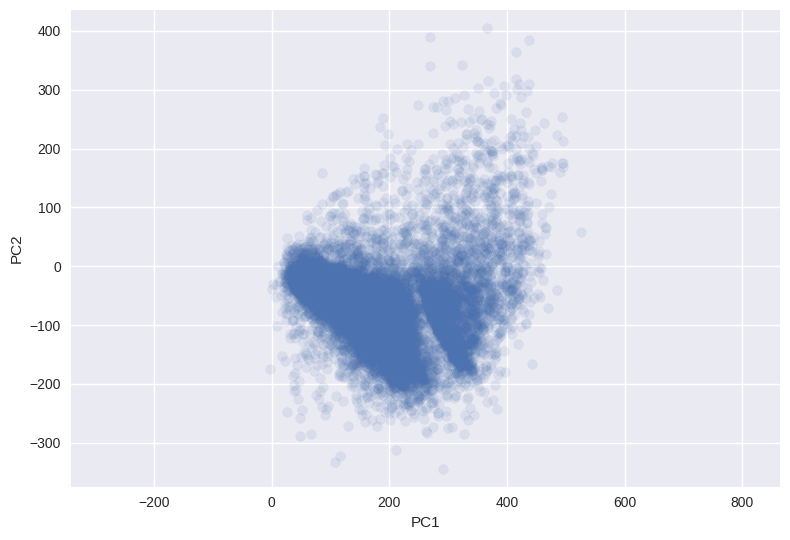

In [15]:
plt.style.use('seaborn')
plt.scatter(coord[:, 0], coord[:, 1], alpha=0.1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.axis('equal')
plt.tight_layout()